In [7]:
import cv2
import numpy as np
import pandas as pd
import os
import zipfile
import matplotlib.pyplot as plt
print('✅ All libraries imported!')

✅ All libraries imported!


In [8]:

ZIP_PATH = r'C:\Users\km080\OneDrive\Desktop\THERMAL PROJECT\Dataset.zip'

BASE_OUT = os.path.join(os.path.dirname(ZIP_PATH), 'thermal_project_output')


EXTRACT_PATH         = os.path.join(BASE_OUT, 'dataset')
PREPROCESS_FOLDER    = os.path.join(BASE_OUT, 'preprocessed_dataset')
ROI_FOLDER           = os.path.join(BASE_OUT, 'roi_dataset')
HEATMAP_FOLDER       = os.path.join(BASE_OUT, 'heatmap_dataset')
CSV_OUTPUT           = os.path.join(BASE_OUT, 'features.csv')

for folder in [EXTRACT_PATH, PREPROCESS_FOLDER, ROI_FOLDER, HEATMAP_FOLDER]:
    os.makedirs(folder, exist_ok=True)

print(f'📁 Output folder : {BASE_OUT}')
print(f'📄 ZIP file      : {ZIP_PATH}')

print('\n📦 Extracting ZIP...')
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)
print('✅ Dataset extracted!')

📁 Output folder : C:\Users\km080\OneDrive\Desktop\THERMAL PROJECT\thermal_project_output
📄 ZIP file      : C:\Users\km080\OneDrive\Desktop\THERMAL PROJECT\Dataset.zip

📦 Extracting ZIP...
✅ Dataset extracted!


## ⚙️ Step 3: Process All Images (Preprocess → ROI → Heatmap → Features)

In [9]:
VALID_EXT = {'.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif'}
features  = []
processed = 0
skipped   = 0

for root, dirs, files_list in os.walk(EXTRACT_PATH):
    for file in files_list:
        ext = os.path.splitext(file)[1].lower()
        if ext not in VALID_EXT:
            skipped += 1
            continue

        path  = os.path.join(root, file)
        image = cv2.imread(path)
        if image is None:
            print(f'⚠️  Could not read: {file}')
            skipped += 1
            continue

        # ── PREPROCESSING ──────────────────────────────────────
        gray       = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        normalized = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)
        gaussian   = cv2.GaussianBlur(normalized, (5, 5), 0)
        filtered   = cv2.medianBlur(gaussian, 5)

        # Save preprocessed image
        pre_name = os.path.splitext(file)[0] + '.png'
        cv2.imwrite(os.path.join(PREPROCESS_FOLDER, pre_name), filtered)

        # ── ROI EXTRACTION ─────────────────────────────────────
        h, w = filtered.shape
        roi  = filtered[int(h*0.3):int(h*0.7), int(w*0.3):int(w*0.7)]
        cv2.imwrite(os.path.join(ROI_FOLDER, pre_name), roi)

        # ── FEATURE EXTRACTION ─────────────────────────────────
        max_temp = float(np.max(roi))
        avg_temp = float(np.mean(roi))
        std_temp = float(np.std(roi))

        gx       = cv2.Sobel(roi, cv2.CV_64F, 1, 0)
        gy       = cv2.Sobel(roi, cv2.CV_64F, 0, 1)
        gradient = float(np.mean(np.sqrt(gx**2 + gy**2)))

        threshold  = np.percentile(roi, 95)
        hot_pixels = roi[roi >= threshold]
        hotspot    = float(np.mean(hot_pixels)) if len(hot_pixels) > 0 else 0.0

        features.append([pre_name, max_temp, avg_temp, std_temp, gradient, hotspot])

        # ── HEATMAP ────────────────────────────────────────────
        heatmap = cv2.applyColorMap(roi, cv2.COLORMAP_JET)
        cv2.imwrite(os.path.join(HEATMAP_FOLDER, pre_name), heatmap)

        processed += 1

print(f'\n✅ Processing Complete!')
print(f'   Images processed : {processed}')
print(f'   Files skipped    : {skipped}')


✅ Processing Complete!
   Images processed : 85
   Files skipped    : 0


In [10]:
df = pd.DataFrame(features, columns=[
    'Image', 'Max_Temperature', 'Average_Temperature',
    'Std_Temperature', 'Thermal_Gradient', 'Hotspot_Intensity'
])

df.to_csv(CSV_OUTPUT, index=False)

print(f'📄 Features CSV saved: {CSV_OUTPUT}')
print(f'   Total rows: {len(df)}')
print()
print(df.round(2).to_string(index=False))

📄 Features CSV saved: C:\Users\km080\OneDrive\Desktop\THERMAL PROJECT\thermal_project_output\features.csv
   Total rows: 85

       Image  Max_Temperature  Average_Temperature  Std_Temperature  Thermal_Gradient  Hotspot_Intensity
 Timage1.png            224.0                41.54            41.56             22.21             197.78
Timage10.png            255.0               103.45            52.55             26.56             247.16
Timage11.png            255.0                91.50            54.62             26.84             243.28
Timage12.png            255.0               102.51            52.08             25.46             246.71
Timage13.png            253.0                69.56            48.76             20.16             229.02
Timage14.png            251.0                57.38            51.45             21.78             224.74
Timage15.png            230.0                52.44            46.63             19.71             205.02
Timage16.png            249.0      

## 🖼️ Step 5: Preview Sample Images

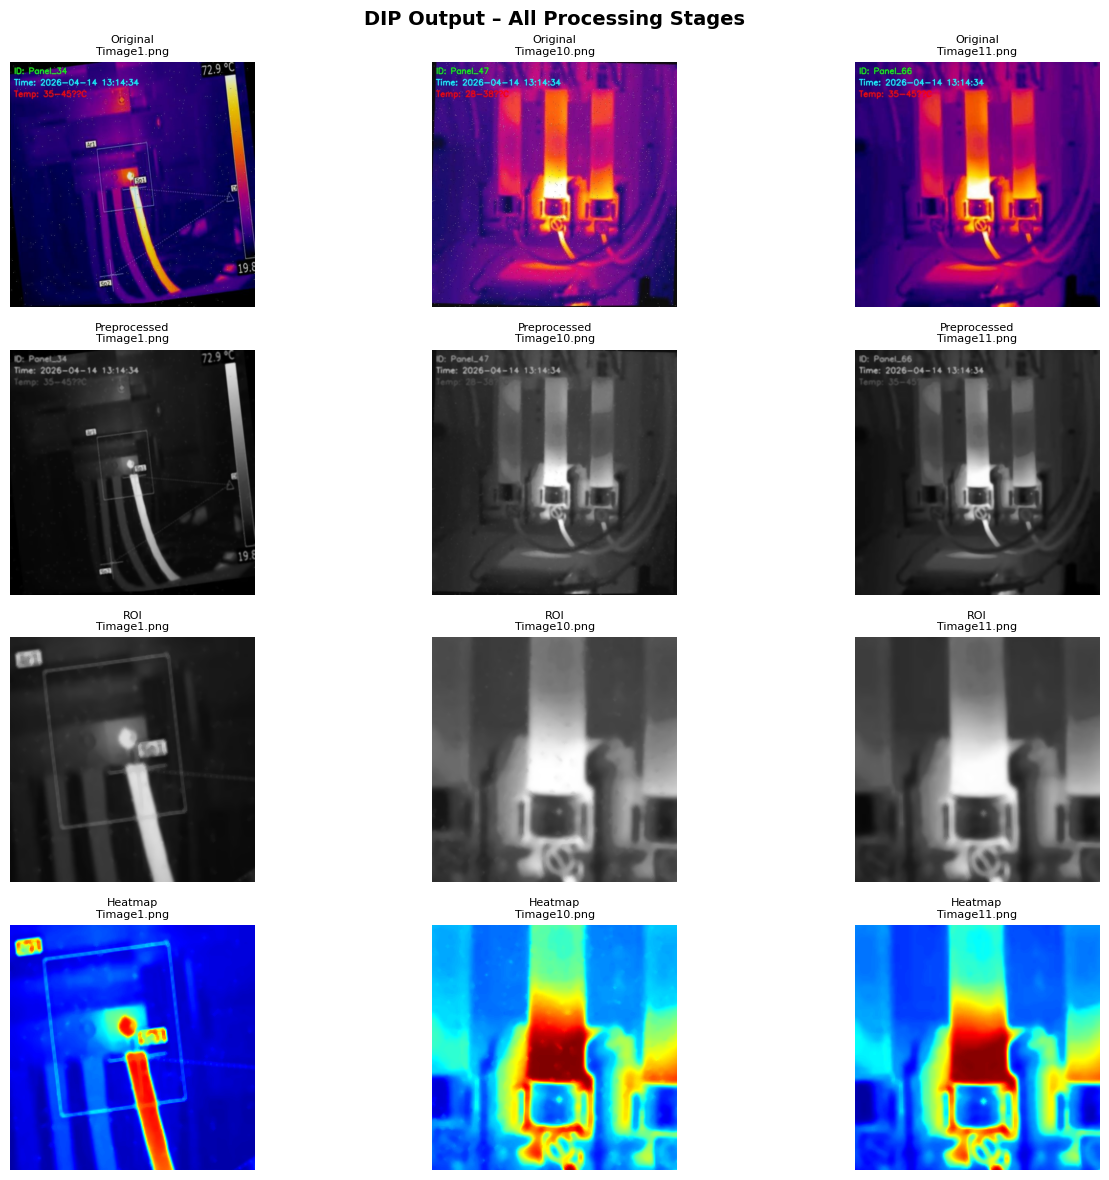

✅ Preview saved: C:\Users\km080\OneDrive\Desktop\THERMAL PROJECT\thermal_project_output\image_preview.png


In [11]:
sample_names = df['Image'].tolist()[:3]

stages = [
    ('Original',     EXTRACT_PATH),
    ('Preprocessed', PREPROCESS_FOLDER),
    ('ROI',          ROI_FOLDER),
    ('Heatmap',      HEATMAP_FOLDER),
]

fig, axes = plt.subplots(len(stages), len(sample_names), figsize=(14, 12))
fig.suptitle("DIP Output – All Processing Stages", fontsize=14, fontweight='bold')

for row, (title, folder) in enumerate(stages):
    for col, img_name in enumerate(sample_names):
        ax = axes[row][col]
        # Try to find the image in folder (original may have different extension)
        found = False
        for candidate in [img_name] + [img_name.replace('.png', ext) for ext in ['.jpg','.jpeg','.bmp']]:
            path = os.path.join(folder, candidate)
            if not os.path.exists(path):
                # Search recursively for original
                for r, d, fl in os.walk(folder):
                    matches = [f for f in fl if os.path.splitext(f)[0] == os.path.splitext(candidate)[0]]
                    if matches:
                        path = os.path.join(r, matches[0])
                        break
            if os.path.exists(path):
                img = cv2.imread(path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img)
                ax.set_title(f'{title}\n{img_name}', fontsize=8)
                found = True
                break
        if not found:
            ax.text(0.5, 0.5, f'{title}\nNot Found', ha='center', va='center', fontsize=9, color='gray')
        ax.axis('off')

plt.tight_layout()
preview_path = os.path.join(BASE_OUT, 'image_preview.png')
plt.savefig(preview_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'✅ Preview saved: {preview_path}')

In [12]:
print(f'  Base Output Folder   : {BASE_OUT}')
print(f'  Preprocessed Images  : {PREPROCESS_FOLDER}')
print(f'  ROI Images           : {ROI_FOLDER}')
print(f'  Heatmap Images       : {HEATMAP_FOLDER}')
print(f'  Feature CSV          : {CSV_OUTPUT}')

  Base Output Folder   : C:\Users\km080\OneDrive\Desktop\THERMAL PROJECT\thermal_project_output
  Preprocessed Images  : C:\Users\km080\OneDrive\Desktop\THERMAL PROJECT\thermal_project_output\preprocessed_dataset
  ROI Images           : C:\Users\km080\OneDrive\Desktop\THERMAL PROJECT\thermal_project_output\roi_dataset
  Heatmap Images       : C:\Users\km080\OneDrive\Desktop\THERMAL PROJECT\thermal_project_output\heatmap_dataset
  Feature CSV          : C:\Users\km080\OneDrive\Desktop\THERMAL PROJECT\thermal_project_output\features.csv
